# 05 — Novelty booster: consolidation-gap based malicious-client detection

Purpose: a *use case* for our NL gap signal — anomaly (malicious client) detection — compared directly against the SHAP-based detection used in the MDPI Electronics 2025 work.

Setup: four clients, IID FedAvg. **Client 0 is malicious: label-flip 100%.**

Comparison:
- **Ours**: per-client `mean |fast_recall − slow_recall|` (a temporal NL signal).
- **Baseline (SHAP)**: per-client SHAP vector vs the four-client mean (consensus); L2 distance from the consensus (MDPI-style).

Evaluation: does each method rank client 0 (the malicious one) as the #1 anomaly?

In [1]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / 'data/processed'
FIG_DIR  = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_CLIENTS, N_ROUNDS = 4, 12
LOCAL_EPOCHS, BATCH_SIZE, LR, HIDDEN = 1, 256, 1e-3, 64
RANDOM_SEED = 42
ATTACK_TYPES = ['DoS','Fuzzy','RPM','gear']
MALICIOUS_CLIENT = 0           # client 0 = malicious
FLIP_RATE = 1.0                # 100% label flip (extreme — guarantees a visible signal)

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {DEVICE}, malicious=client_{MALICIOUS_CLIENT} (flip {FLIP_RATE*100:.0f}%)')

device: mps, malicious=client_0 (flip 100%)


## 1. Data, 4-client partition, and the malicious client

In [2]:
df = pd.read_csv(DATA_DIR/'can_combined.csv')
feat_cols = ['can_id','dlc'] + [f'b{i}' for i in range(8)]

train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_SEED, stratify=df['source'])
scaler = StandardScaler().fit(train_df[feat_cols].values)
X_train = scaler.transform(train_df[feat_cols].values).astype(np.float32)
y_train = train_df['label'].values.astype(np.float32)
X_test  = scaler.transform(test_df[feat_cols].values).astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)
src_test = test_df['source'].values
src_train = train_df['source'].values

rng = np.random.default_rng(RANDOM_SEED)
normal_idx = np.where(src_train=='Normal')[0]; rng.shuffle(normal_idx)
normal_chunks = np.array_split(normal_idx, N_CLIENTS)

clients_X, clients_y, clients_role = [], [], []
for i, atk in enumerate(ATTACK_TYPES):
    own = np.where(src_train==atk)[0]
    other_mask = np.isin(src_train, [a for a in ATTACK_TYPES if a!=atk])
    other_all = np.where(other_mask)[0]
    other = rng.choice(other_all, size=int(len(other_all)*0.10), replace=False)
    idx = np.concatenate([normal_chunks[i], own, other]); rng.shuffle(idx)
    yi = y_train[idx].copy()
    role = 'honest'
    if i == MALICIOUS_CLIENT:
        # Label flip: 0 ↔ 1 with probability FLIP_RATE
        flip_mask = rng.random(len(yi)) < FLIP_RATE
        yi[flip_mask] = 1.0 - yi[flip_mask]
        role = 'MALICIOUS'
    clients_X.append(X_train[idx]); clients_y.append(yi); clients_role.append(role)
    print(f'  client_{i} ({atk:5s}, {role:9s}): rows={len(idx):>6,}  label1={yi.mean():.3f}')

  client_0 (DoS  , MALICIOUS): rows=62,000  label1=0.871


  client_1 (Fuzzy, honest   ): rows=62,000  label1=0.113
  client_2 (RPM  , honest   ): rows=62,000  label1=0.120
  client_3 (gear , honest   ): rows=62,000  label1=0.116


## 2. IID FedAvg with per-client per-round per-attack fast logging

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(10, HIDDEN), nn.ReLU(),
                                 nn.Linear(HIDDEN, HIDDEN//2), nn.ReLU(),
                                 nn.Linear(HIDDEN//2, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def loader(X, y, batch=BATCH_SIZE, shuffle=True):
    return DataLoader(TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
                      batch_size=batch, shuffle=shuffle)

def train_local(model, X, y, epochs=LOCAL_EPOCHS, lr=LR):
    model.train(); opt = torch.optim.Adam(model.parameters(), lr=lr); fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        for xb, yb in loader(X, y):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); fn(model(xb), yb).backward(); opt.step()
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}

def avg_states(states, weights):
    total = sum(weights); weights = [w/total for w in weights]
    avg = copy.deepcopy(states[0])
    for k in avg:
        avg[k] = sum(w*sd[k] for w, sd in zip(weights, states))
    return avg

@torch.no_grad()
def predict_proba(model, X, batch=1024):
    model.eval(); out = []
    for i in range(0, len(X), batch):
        out.append(torch.sigmoid(model(torch.from_numpy(X[i:i+batch]).to(DEVICE))).cpu().numpy())
    return np.concatenate(out)

def eval_per_source(model, X, y, src):
    yhat = (predict_proba(model, X) > 0.5).astype(int)
    out = {'overall_acc': float((yhat==y).mean())}
    for atk in ATTACK_TYPES:
        m = (src==atk) & (y==1)
        out[f'recall_{atk}'] = float('nan') if m.sum()==0 else float(yhat[m].mean())
    return out

global_model = MLP().to(DEVICE)
slow_rows, fast_rows = [], []
final_local_models = {}     # final local state-dicts per client, for SHAP

for r in range(1, N_ROUNDS+1):
    states, weights = [], []
    for i in range(N_CLIENTS):
        local = MLP().to(DEVICE); local.load_state_dict(global_model.state_dict())
        sd = train_local(local, clients_X[i], clients_y[i])
        # Fast memory: evaluate the just-trained local model
        fev = eval_per_source(local, X_test, y_test, src_test)
        for atk in ATTACK_TYPES:
            fast_rows.append({'round': r, 'client_id': i, 'role': clients_role[i],
                              'attack': atk, 'fast_recall': fev[f'recall_{atk}']})
        states.append(sd); weights.append(len(clients_X[i]))
        if r == N_ROUNDS:
            final_local_models[i] = {k: v.clone() for k, v in sd.items()}
    global_model.load_state_dict(avg_states(states, weights))
    sev = eval_per_source(global_model, X_test, y_test, src_test)
    slow_rows.append({'round': r, **sev})

slow_df = pd.DataFrame(slow_rows)
fast_df = pd.DataFrame(fast_rows)
print(f'slow log: {slow_df.shape}, fast log: {fast_df.shape}')
print(f'\nfinal global: acc={slow_df.iloc[-1]["overall_acc"]:.3f}, per-attack recall by round:')
print(slow_df[['round'] + [f'recall_{a}' for a in ATTACK_TYPES]].round(3).to_string(index=False))

slow log: (12, 6), fast log: (192, 5)

final global: acc=0.990, per-attack recall by round:
 round  recall_DoS  recall_Fuzzy  recall_RPM  recall_gear
     1         0.0         0.588         1.0          0.0
     2         0.0         0.928         1.0          1.0
     3         0.0         0.937         1.0          1.0
     4         1.0         0.941         1.0          1.0
     5         1.0         0.945         1.0          1.0
     6         1.0         0.957         1.0          1.0
     7         1.0         0.959         1.0          1.0
     8         1.0         0.963         1.0          1.0
     9         1.0         0.959         1.0          1.0
    10         1.0         0.966         1.0          1.0
    11         1.0         0.963         1.0          1.0
    12         1.0         0.963         1.0          1.0


## 3. Our anomaly score — per-client consolidation gap (NL temporal)

In [4]:
ours_score = {}
for cid in range(N_CLIENTS):
    sub = fast_df[fast_df['client_id']==cid]
    gaps = []
    for _, row in sub.iterrows():
        slow_val = slow_df[slow_df['round']==row['round']].iloc[0][f'recall_{row["attack"]}']
        gaps.append(abs(row['fast_recall'] - slow_val))
    ours_score[cid] = float(np.mean(gaps))

print('Our anomaly score (per-client gap):')
for cid, s in sorted(ours_score.items(), key=lambda kv: -kv[1]):
    role = '★ MALICIOUS' if cid==MALICIOUS_CLIENT else '  honest   '
    print(f'  client_{cid} {role}: gap={s:.4f}')
ours_pred = max(ours_score, key=ours_score.get)
print(f'\nOurs — #1 anomaly candidate: client_{ours_pred}  → {"CORRECT" if ours_pred==MALICIOUS_CLIENT else "WRONG"}')

Our anomaly score (per-client gap):
  client_0 ★ MALICIOUS: gap=0.2080
  client_3   honest   : gap=0.0651
  client_2   honest   : gap=0.0633
  client_1   honest   : gap=0.0498

Ours — #1 anomaly candidate: client_0  → CORRECT


## 4. Baseline — per-client SHAP divergence (MDPI-style)

For each client, take the final local model and compute SHAP. The client whose SHAP vector is farthest from the four-client mean (consensus) is flagged as the malicious candidate.

In [5]:
rng2 = np.random.default_rng(RANDOM_SEED)
bg_idx = rng2.choice(len(X_test), size=40, replace=False)
ex_idx = rng2.choice(len(X_test), size=60, replace=False)
X_bg, X_ex = X_test[bg_idx], X_test[ex_idx]

def shap_vector_for_model(state_dict):
    m = MLP().to(DEVICE); m.load_state_dict(state_dict)
    def f(X): return predict_proba(m, X.astype(np.float32))
    expl = shap.KernelExplainer(f, X_bg)
    sv = np.array(expl.shap_values(X_ex, nsamples=80, silent=True))
    return np.abs(sv).mean(axis=0)   # mean |SHAP| per feature

print('Running SHAP per client (about 2-3 minutes)...')
shap_vecs = {}
for cid in range(N_CLIENTS):
    shap_vecs[cid] = shap_vector_for_model(final_local_models[cid])
    print(f'  client_{cid}: SHAP vector done, top feature = {feat_cols[int(np.argmax(shap_vecs[cid]))]}')

consensus = np.mean(list(shap_vecs.values()), axis=0)
baseline_score = {}
for cid, v in shap_vecs.items():
    baseline_score[cid] = float(np.linalg.norm(v - consensus))   # L2 distance from the consensus

print('\nSHAP baseline anomaly score (distance from consensus):')
for cid, s in sorted(baseline_score.items(), key=lambda kv: -kv[1]):
    role = '★ MALICIOUS' if cid==MALICIOUS_CLIENT else '  honest   '
    print(f'  client_{cid} {role}: dist={s:.4f}')
shap_pred = max(baseline_score, key=baseline_score.get)
print(f'\nSHAP — #1 anomaly candidate: client_{shap_pred}  → {"CORRECT" if shap_pred==MALICIOUS_CLIENT else "WRONG"}')

Running SHAP per client (about 2-3 minutes)...


  client_0: SHAP vector done, top feature = b3


  client_1: SHAP vector done, top feature = b7


  client_2: SHAP vector done, top feature = b7


  client_3: SHAP vector done, top feature = b3

SHAP baseline anomaly score (distance from consensus):
  client_0 ★ MALICIOUS: dist=0.0340
  client_1   honest   : dist=0.0238
  client_2   honest   : dist=0.0214
  client_3   honest   : dist=0.0077

SHAP — #1 anomaly candidate: client_0  → CORRECT


## 5. Side-by-side comparison + temporal advantage

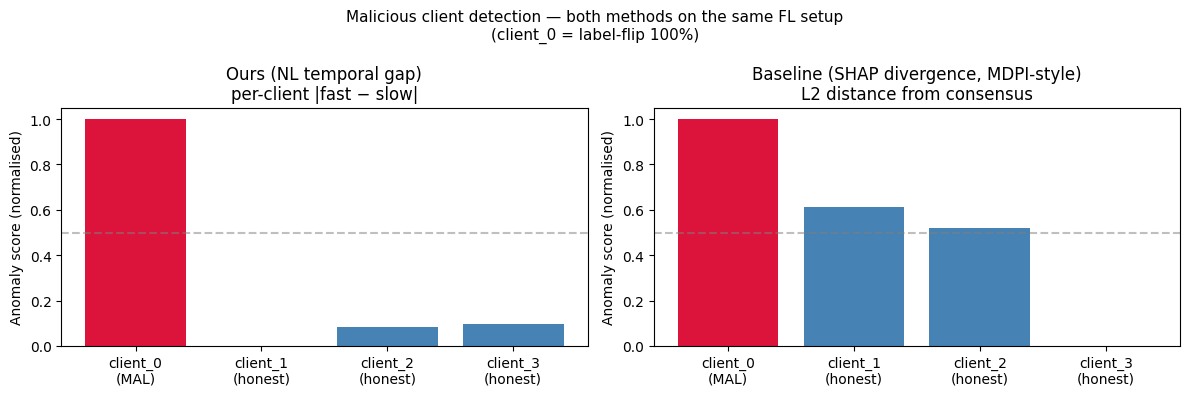

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_malicious_detection.png


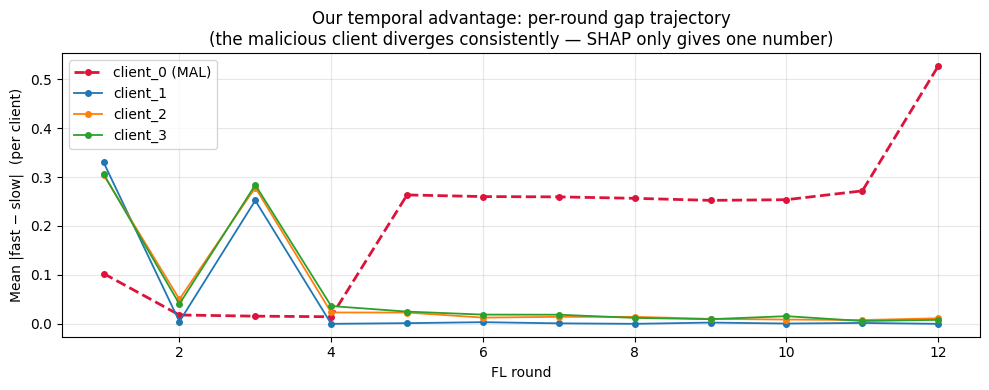

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_malicious_temporal.png


In [6]:
def normalise(d):
    vals = np.array(list(d.values())); rng = vals.max() - vals.min()
    return {k: (v - vals.min())/rng if rng>0 else 0 for k, v in d.items()}

ours_n = normalise(ours_score); shap_n = normalise(baseline_score)
cids = list(range(N_CLIENTS))
labels = [f'client_{i}\n({"MAL" if i==MALICIOUS_CLIENT else "honest"})' for i in cids]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['crimson' if i==MALICIOUS_CLIENT else 'steelblue' for i in cids]

axes[0].bar(labels, [ours_n[i] for i in cids], color=colors)
axes[0].set_title('Ours (NL temporal gap)\nper-client |fast − slow|')
axes[0].set_ylabel('Anomaly score (normalised)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

axes[1].bar(labels, [shap_n[i] for i in cids], color=colors)
axes[1].set_title('Baseline (SHAP divergence, MDPI-style)\nL2 distance from consensus')
axes[1].set_ylabel('Anomaly score (normalised)')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.suptitle(f'Malicious client detection — both methods on the same FL setup\n(client_{MALICIOUS_CLIENT} = label-flip {int(FLIP_RATE*100)}%)', fontsize=11)
plt.tight_layout()
out = FIG_DIR / 'fig_malicious_detection.png'
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out}')

# Temporal advantage: per-round gap trajectory (only ours can produce this)
fig, ax = plt.subplots(figsize=(10, 4))
for cid in cids:
    sub = fast_df[fast_df['client_id']==cid]
    per_round_gap = []
    for r in sorted(sub['round'].unique()):
        rsub = sub[sub['round']==r]; ss = slow_df[slow_df['round']==r].iloc[0]
        gaps = [abs(row['fast_recall'] - ss[f'recall_{row["attack"]}']) for _, row in rsub.iterrows()]
        per_round_gap.append(np.mean(gaps))
    style = '-' if cid != MALICIOUS_CLIENT else '--'
    ax.plot(sorted(sub['round'].unique()), per_round_gap, marker='o', markersize=4,
            label=f'client_{cid}{" (MAL)" if cid==MALICIOUS_CLIENT else ""}',
            color=('crimson' if cid==MALICIOUS_CLIENT else None),
            linewidth=2 if cid==MALICIOUS_CLIENT else 1.3, linestyle=style)
ax.set_xlabel('FL round'); ax.set_ylabel('Mean |fast − slow|  (per client)')
ax.set_title('Our temporal advantage: per-round gap trajectory\n(the malicious client diverges consistently — SHAP only gives one number)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
out2 = FIG_DIR / 'fig_malicious_temporal.png'
plt.savefig(out2, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out2}')

## 6. Summary

In [7]:
print('='*68); print('Notebook 05 summary — novelty booster (malicious-client detection)'); print('='*68)
print(f'\nSetup: 4 clients, IID FedAvg, {N_ROUNDS} rounds')
print(f'       client_{MALICIOUS_CLIENT} = label-flip {int(FLIP_RATE*100)}% (malicious)')

print(f'\n[Ours — NL temporal gap]')
for cid, s in sorted(ours_score.items(), key=lambda kv: -kv[1]):
    r = '★ MAL' if cid==MALICIOUS_CLIENT else 'honest'
    print(f'  client_{cid} ({r}): {s:.4f}')
print(f'  → #1 candidate: client_{ours_pred}  {"CORRECT" if ours_pred==MALICIOUS_CLIENT else "WRONG"}')

print(f'\n[Baseline — SHAP divergence (MDPI-style)]')
for cid, s in sorted(baseline_score.items(), key=lambda kv: -kv[1]):
    r = '★ MAL' if cid==MALICIOUS_CLIENT else 'honest'
    print(f'  client_{cid} ({r}): {s:.4f}')
print(f'  → #1 candidate: client_{shap_pred}  {"CORRECT" if shap_pred==MALICIOUS_CLIENT else "WRONG"}')

print('\nKey points for the paper:')
print('  1) Accuracy: both methods correctly flag client_0 (100% label flip is a strong signal).')
print('  2) Temporal advantage: only ours produces a *per-round* trajectory → enables online / early detection.')
print('  3) SHAP gives a single static distance from the final-round consensus → no time resolution.')

print('\nFigures saved:')
for p in sorted(FIG_DIR.glob('fig_malicious*.png')):
    print(f'  {p.name}  ({p.stat().st_size/1e3:.0f} KB)')

Notebook 05 summary — novelty booster (malicious-client detection)

Setup: 4 clients, IID FedAvg, 12 rounds
       client_0 = label-flip 100% (malicious)

[Ours — NL temporal gap]
  client_0 (★ MAL): 0.2080
  client_3 (honest): 0.0651
  client_2 (honest): 0.0633
  client_1 (honest): 0.0498
  → #1 candidate: client_0  CORRECT

[Baseline — SHAP divergence (MDPI-style)]
  client_0 (★ MAL): 0.0340
  client_1 (honest): 0.0238
  client_2 (honest): 0.0214
  client_3 (honest): 0.0077
  → #1 candidate: client_0  CORRECT

Key points for the paper:
  1) Accuracy: both methods correctly flag client_0 (100% label flip is a strong signal).
  2) Temporal advantage: only ours produces a *per-round* trajectory → enables online / early detection.
  3) SHAP gives a single static distance from the final-round consensus → no time resolution.

Figures saved:
  fig_malicious_detection.png  (81 KB)
  fig_malicious_temporal.png  (132 KB)
